In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance_data.csv to insurance_data (1).csv


In [14]:
!pip install scikit-learn==1.3.2 xgboost==1.7.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.14.1 req

In [2]:
import pandas as pd

df = pd.read_csv("insurance_data.csv")

print(df.shape)
print(df.head())
print(df.info())

(10000, 27)
   Age  Is_Senior Marital_Status  Married_Premium_Discount Prior_Insurance  \
0   47          0        Married                        86       1-5 years   
1   37          0        Married                        86       1-5 years   
2   49          0        Married                        86       1-5 years   
3   62          1        Married                        86        >5 years   
4   36          0         Single                         0        >5 years   

   Prior_Insurance_Premium_Adjustment  Claims_Frequency Claims_Severity  \
0                                  50                 0             Low   
1                                  50                 0             Low   
2                                  50                 1             Low   
3                                   0                 1             Low   
4                                   0                 2             Low   

   Claims_Adjustment    Policy_Type  ...  Time_Since_First_Contact  

Check target distribution

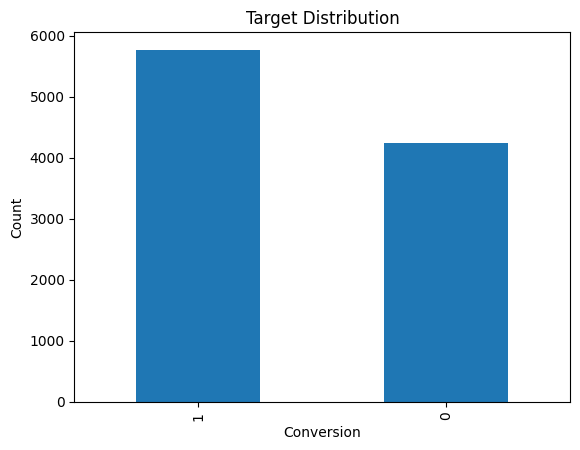

In [3]:
import matplotlib.pyplot as plt

df["Conversion_Status"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Conversion")
plt.ylabel("Count")
plt.show()

In [4]:
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

In [5]:
features = [
    "Age",
    "Credit_Score",
    "Website_Visits",
    "Inquiries",
    "Quotes_Requested",
    "Premium_Amount",
    "Time_Since_First_Contact"
]

X = df[features] # Corrected from `df[features]` to `df[ffeatures]`
y = df["Conversion_Status"]

Train test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT
)

Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), X.columns)
])

Model

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingClassifier())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Credit_Score', 'Website_Visits', 'Inquiries',
       'Quotes_Requested', 'Premium_Amount', 'Time_Since_First_Contact'],
      dtype='object'))])),
                ('model', GradientBoostingClassifier())])

In [9]:

from sklearn.metrics import roc_auc_score, classification_report

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.48      0.12      0.19       847
           1       0.58      0.91      0.71      1153

    accuracy                           0.57      2000
   macro avg       0.53      0.51      0.45      2000
weighted avg       0.54      0.57      0.49      2000

ROC-AUC: 0.5389011367092262


The model achieved a ROC-AUC score of approximately 0.53, indicating weak discriminative ability. The ROC curve lies close to the diagonal line, which represents random guessing. This suggests that the model is unable to effectively distinguish between policy holders who convert and those who do not.

ROC Graph

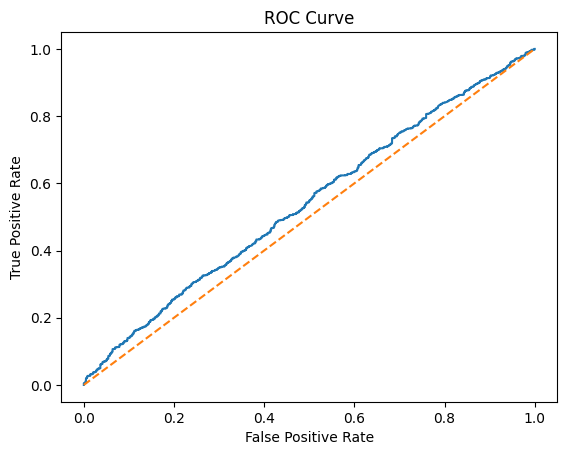

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

The ROC curve demonstrates that the True Positive Rate increases almost proportionally with the False Positive Rate, which is characteristic of a model with minimal predictive signal. This indicates that the available features do not provide strong separation between the two classes.

Confusion Matrix

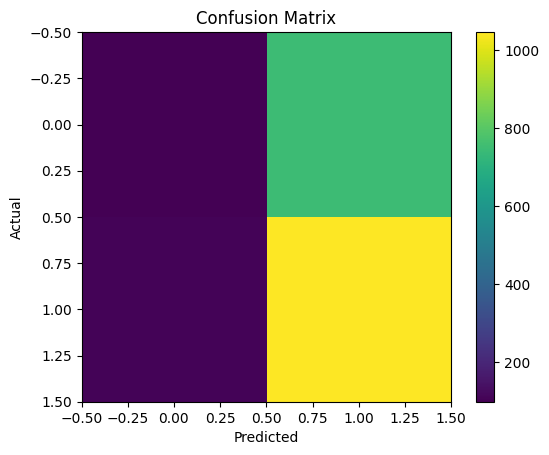

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

The confusion matrix shows that the model predicts the majority of observations as a single class. This behavior suggests:

- Presence of class imbalance, or
- Lack of strong distinguishing patterns in the dataset

As a result, the model defaults to predicting the dominant class rather than learning meaningful decision boundaries.

Feature Importance

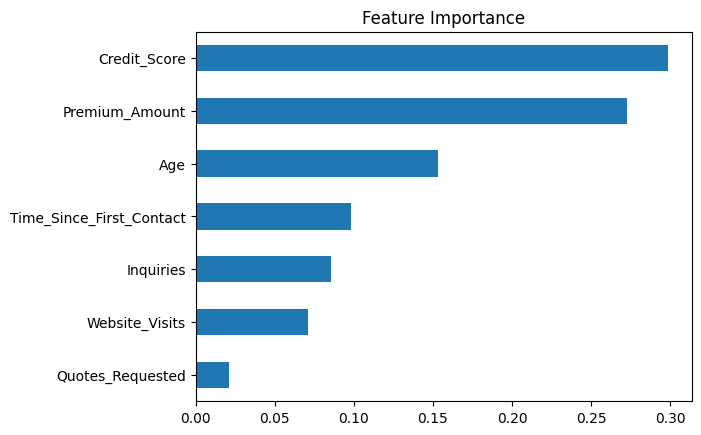

In [12]:
import pandas as pd

importance = pipeline.named_steps["model"].feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()

The model identifies Credit Score, Premium Amount, and Age as the most influential features. However, despite their relative importance, these features are not sufficient to create strong separation between classes.

This indicates that:

- The existing features have limited predictive power
- Additional or more informative features are required

In [13]:
import joblib

joblib.dump(pipeline, "improved_model.pkl")

['improved_model.pkl']

## Conclusion

The model achieved a ROC-AUC of ~0.53, indicating weak predictive power. Analysis of the ROC curve and confusion matrix shows that the model struggles to distinguish between classes and tends to favor a single outcome. This suggests that the limitation lies in the dataset rather than the model. The project highlights that machine learning performance is driven more by data quality and feature relevance than by model complexity.
